In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape, Polygon

import pandas as pd
plt.style.use('robin')
from matplotlib.colors import LogNorm, Normalize
proj = ccrs.NorthPolarStereo(0,70)
import dask.bag as db

def sigmoid(x):
    return 1/(1+np.exp(-x))
def logit(x):
    return np.log(x/(1-x)) 

In [2]:
cluster = LocalCluster(n_workers=4, memory_limit='12GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 64,Total memory: 48.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35273,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34501,Total threads: 16
Dashboard: http://127.0.0.1:37979/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:41807,


# Load experiments results

In [3]:
run_id = 'h82d4u1m'
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v3_lrpzplus.nc', chunks = dict(time_of_event=20)).load().transpose('y','x',...)

grid = ds_attrs.isel(time_of_event=0, timestep_past=0, var_name=0).attributions_lrp
lrp_normed = ds_attrs.attributions_lrp.sum('var_name')#/normalize
lrp_normed = lrp_normed/lrp_normed.clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed

# cycs = cycs.query("msl<100000")
ds_attrs

<xarray.Dataset> Size: 2GB
Dimensions:           (time_of_event: 840, y: 128, x: 128, timestep_past: 7,
                       var_name: 3)
Coordinates:
    quantile          float64 8B 0.95
  * x                 (x) float64 1kB -1e+07 -9.882e+06 ... 4.882e+06 5e+06
  * y                 (y) float64 1kB -1e+07 -9.882e+06 ... 4.882e+06 5e+06
  * var_name          (var_name) <U4 48B 'u850' 'v850' 'msl'
    lat               (y, x) float32 66kB -7.882 -7.545 -7.207 ... 31.09 30.5
    lon               (y, x) float32 66kB -45.0 -44.66 -44.32 ... 135.7 135.0
  * timestep_past     (timestep_past) int64 56B -6 -5 -4 -3 -2 -1 0
  * time_of_event     (time_of_event) datetime64[ns] 7kB 1979-01-07 ... 2024-...
Data variables:
    rain              (time_of_event) float64 7kB 30.89 37.58 ... 31.53 28.58
    targets           (time_of_event) float64 7kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    attributions_lrp  (y, x, time_of_event, timestep_past, var_name) float32 1GB ...
    predictions       (time_of_event, timestep_past) float32 24kB 1.638 ... 4...
    lrp_normed        (y, x, time_of_event, timestep_past) float32 385MB -1.9...

# Cyclones stuff

## Load cyclone data

In [4]:
all_df_dailys = []
import glob
files = glob.glob('/Data/gfi/share/Reanalyses/ERA-5/detected_features/cyclone_tracks_melbourne/*.pos.nc')
files = [f for f in files if f.endswith('.nc')]
proj_stereo = CRS(f"+proj=stere +lat_0=90 +lat_ts=70 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +units=m")
transformer = Transformer.from_crs("EPSG:4326", proj_stereo, always_xy=True)
for file in tqdm(files):
    with xr.open_dataset(file) as ds:
        df_ = ds[['track_id', 'lon','lat','msl','date']].to_dataframe()
        df_['date'] = pd.to_datetime(df_.date.dt.date)
        df_daily = df_.groupby(['date','track_id']).agg({'msl':'min','lon':'mean','lat':'mean'}).reset_index()   
        x,y = transformer.transform(df_daily['lon'].values, df_daily['lat'].values)
        df_daily['x'] = x
        df_daily['y'] = y
        all_df_dailys.append(df_daily)
        del df_
daily_cycs = pd.concat(all_df_dailys)
daily_cycs = daily_cycs.loc[(daily_cycs.x > -1e7)&(daily_cycs.x < .5e7)&(daily_cycs.y > -1e7)&(daily_cycs.y < .5e7)]
daily_cycs = daily_cycs.set_index('date').sort_index()
daily_cycs['track_id']=daily_cycs['track_id'].astype(int)#.astype(float)
daily_cycs['key'] = daily_cycs.index.strftime("%Y-%m-%d") + ' '+daily_cycs.track_id.astype(str)


cyclones_gdf = gpd.GeoDataFrame(
    daily_cycs.reset_index(),
    geometry=gpd.points_from_xy(daily_cycs["x"], daily_cycs["y"]),
    crs=proj  # adjust if your cyclones are in another CRS
).set_index('date')


  0%|          | 0/552 [00:00<?, ?it/s]

## Compute aggregation with Moran's I


In [ ]:
from esda.moran import Moran
from libpysal.weights import KNN, DistanceBand,lat2W


times = ds_attrs.time_of_event.sel(time_of_event=slice('1979', '2024')).values

data = ds_attrs.sel(time_of_event='2016-08-09').sel(timestep_past=0).lrp_normed

X = data.to_dataframe().lrp_normed.reset_index().x.values
Y = data.to_dataframe().lrp_normed.reset_index().y.values
coords = np.column_stack([X, Y])
w = lat2W(nrows=X.size, ncols=Y.size, rook=False) # Queen's case

results = []

for time_of_event in tqdm(times):
    for timestep_past in range(-6,1):
        data_ = ds_attrs.sel(time_of_event=time_of_event).sel(timestep_past=timestep_past).lrp_normed
        numbers = data_.values.flatten()
        mi = Moran(numbers,w)
        results.append([time_of_event, timestep_past, mi.I, mi.p_sim])


ds = pd.DataFrame(results, columns = ['time_of_event','timestep_past','Moran_I','p_value']).set_index(['time_of_event','timestep_past']).to_xarray()
ds.to_netcdf(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2_lrpgamma.nc')

## Define processing functions

In [5]:
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi


def get_gdf_from_segment_grid(segments):
    x = segments.x.values
    y = segments.y.values
    labels = segments.values
    dx = float(np.mean(np.diff(x))) 
    dy = float(np.mean(np.diff(y))) 
    x0 = x.min() - dx / 2.0
    y0 = y.min() - dy / 2.0  
    transform = Affine.translation(x0, y0) * Affine.scale(dx, dy)
    geoms = []
    vals = []
    for geom, value in features.shapes(labels, transform=transform):
        if value == 0:
            continue
        geoms.append(shape(geom))
        vals.append(value)
    gdf_segments = gpd.GeoDataFrame(
        {"label": vals},
        geometry=geoms,
        crs="EPSG:3413"   # or "EPSG:3995" or your custom proj string
    )
    gdf_segments= gdf_segments.set_index('label') 
    gdf_segments=gdf_segments.reset_index().dissolve(by='label')
    return gdf_segments

def segments_from_attribution_grid_watershed_v2(time_of_event, timestep_past, ds_attrs,abs_threshold = 0.0005, rolling=5):
    data = ds_attrs.sel(time_of_event=time_of_event,timestep_past=timestep_past).lrp_normed
    data = data.rio.write_crs(proj) 
    img = data.rolling(x=rolling, y=rolling, center=True).mean()
    img_filter = img.where(np.abs(img)>abs_threshold).fillna(0)
    img_filter = np.abs(img_filter)
    distance = ndi.distance_transform_edt(img_filter>0)
    peaks = peak_local_max(
    distance,
    min_distance=4,
    labels=img_filter>0
    )
    if len(peaks)==0:
        return None, data
    markers = np.zeros_like(img, dtype=int)
    for i, (r, c) in enumerate(peaks, start=1):
        markers[r, c] = i

    labels = watershed(-distance, markers, mask=img_filter>0)
    patch_labels = xr.DataArray(labels, dims=img.dims, coords=img.coords)
    patch_labels = patch_labels.where(labels>0)
    
    attributions = img.groupby(patch_labels).sum()

    gdf_patches = get_gdf_from_segment_grid(patch_labels)
    gdf_patches['patch_attributions'] = attributions.values
    gdf_patches['patch_area'] = gdf_patches.geometry.area/1_000_000
    gdf_patches['patch_pixel_count'] = np.round(gdf_patches.patch_area/117/117)
    return gdf_patches, data

def get_cyclones_for_day(time_of_event, timestep_past):
    time = pd.to_datetime(time_of_event) + pd.Timedelta(f'{timestep_past}D')
    cyclones_gdf_day = cyclones_gdf.loc[time.strftime("%Y-%m-%d")]
    return cyclones_gdf_day.set_index('track_id')

def get_top_cycs_area_overlap(series):
        geom = gpd.GeoDataFrame(geometry=series)
        if np.isnan(geom.area.max()):
            return np.nan
        else:
            return geom.area.idxmax()

# def get_best_cycs_per_distance(series, cyclones_gdf_day, gdf_patches):
#     cycs_available_index = series.dropna().index
#     if len(cycs_available_index) == 0:
#         return np.nan
#     cycs_available = cyclones_gdf_day.loc[cycs_available_index].geometry
#     dist = cycs_available.distance(gdf_patches.loc[series.name].location_local_max)
#     return dist.idxmax()

def attribution_patches_to_cyclones(gdf_patches,cyclones_gdf_day, buffer=500_000):
    geom = gdf_patches.geometry.apply(lambda g: cyclones_gdf_day.buffer(buffer).intersection(g).loc[cyclones_gdf_day.buffer(buffer).intersects(g)])
    track_id = geom.apply(get_top_cycs_area_overlap, axis=1)
    gdf_patches['cyclone_track_id'] = track_id.values
    gdf_patches['patch_area'] = gdf_patches.area
    gdf_patches['patch_pixel_count'] = np.round(gdf_patches.patch_area/117000/117000)
    gdf_patches = gdf_patches
    return gdf_patches

def group_cyclones(gdf_patches):
    cyclone_groups = gdf_patches.groupby('cyclone_track_id')[['patch_attributions','patch_area','patch_pixel_count']].sum()
    gdf_patches_cyclones = gpd.GeoDataFrame(cyclone_groups, geometry = gdf_patches.dissolve(by='cyclone_track_id').geometry)
    gdf_patches_cyclones['patch_area'] = gdf_patches_cyclones.area
    gdf_patches_cyclones['patch_pixel_count'] = np.round(gdf_patches_cyclones.patch_area/117000/117000)    
    gdf_patches_cyclones = gdf_patches_cyclones.reset_index()
    gdf_no_cycs = gdf_patches.loc[gdf_patches.cyclone_track_id.isnull()][gdf_patches_cyclones.columns]
    if gdf_no_cycs.index.size>0:
        gdf_patches_cyclones = pd.concat([gdf_patches_cyclones, gdf_no_cycs])
    return gdf_patches_cyclones


# gdf_patches, data = segments_from_attribution_grid_watershed_v2(time_of_event,timestep_past, ds_attrs,abs_threshold = 0.0005, rolling=5)
# cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
# gdf_patches = attribution_patches_to_cyclones(gdf_patches, cyclones_gdf_day)
# gdf_patches_cyclones = group_cyclones(gdf_patches)
# # gdf_patches.groupby(#.dissolve()#.plot(cmap='viridis')
# # data.plot()
# fig, ax = plt.subplots()
# gdf_patches_cyclones.plot(cmap='viridis',ax=ax)
# # cyclones_gdf_day.buffer(500_000).plot(ax=ax)
# gdf_patches_cyclones.reset_index()


<Axes: >

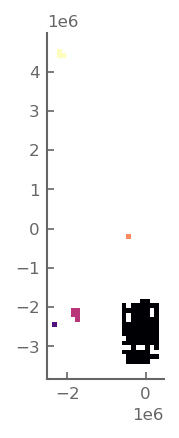

In [6]:
time_of_event = '2024-12-18'
timestep_past=-3
gdf_patches, data = segments_from_attribution_grid_watershed_v2(time_of_event,timestep_past, ds_attrs,abs_threshold = 0.001, rolling=1)

gdf_patches.plot(cmap='magma')

In [11]:
# ds_attrs_randomized = 
time_random = np.copy(ds_attrs.time_of_event.values)
np.random.seed(42)
np.random.shuffle(time_random)
ds_attrs_randomized = ds_attrs.assign_coords(time_of_event=time_random).sortby('time_of_event')

In [20]:
times = ds_attrs.time_of_event.sel(time_of_event=slice(None, '2024')).values
all_gdf_segments = []
for time_of_event in tqdm(times):
    for timestep_past in range(-6,1):
        gdf_patches, data = segments_from_attribution_grid_watershed_v2(time_of_event,timestep_past, ds_attrs,abs_threshold = 0.001, rolling=1)
        if gdf_patches is not None:
            cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
            gdf_patches = attribution_patches_to_cyclones(gdf_patches, cyclones_gdf_day, buffer=500_000)
            gdf_patches_cyclones = group_cyclones(gdf_patches)
            gdf_patches_cyclones['time_of_event'] = time_of_event
            gdf_patches_cyclones['timestep_past'] = timestep_past            
            all_gdf_segments.append(gdf_patches_cyclones)
            
df_ = pd.concat(all_gdf_segments)
df_['is_cyclone'] = df_.cyclone_track_id.notnull()
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.patch_area<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.patch_attributions)<.05)&(df_.patch_area>0.1e7)).values] = 'large neutral'
categories[((df_.patch_attributions<-.05)&(df_.patch_area>0.1e7)).values] = 'large negative'
categories[((df_.patch_attributions>.05)&(df_.patch_area>0.1e7)).values] = 'large positive'
df_['patch_category'] = categories

key = (df_.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+df_.reset_index().cyclone_track_id.fillna(0).astype(int).astype(str)).values
key[df_.cyclone_track_id.isnull()] = '1979-01-02 0'
df_['key'] = key
df_ = df_.set_index(key)
daily_cycs_for_patches = daily_cycs.reset_index().set_index('key').loc[df_.key]
df_[['cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = daily_cycs_for_patches[['msl','lon','lat','x','y']].values

df_ = df_.reset_index().rename(columns=dict( date='cyclone_date',segment_size='blob_area', attributions='blob_attributions'))
df_.loc[df_.cyclone_track_id.isnull(), ['key','cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = np.nan
df_['is_cyclone'] = df_.cyclone_track_id.notnull()
gdf_cyclones = df_
df_.to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data_watershed_thresh0.001_buffer500_v2_zplus_rolling1.geojson', driver='GeoJSON')
# 
# df_ = df_.rename(columns=dict(track_id='cyclones'))

  0%|          | 0/840 [00:00<?, ?it/s]

<Axes: xlabel='timestep_past'>

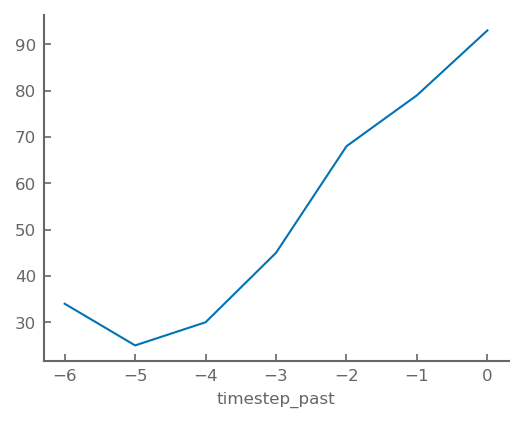

In [17]:
(gdf_cyclones.query("is_cyclone & patch_attributions>0.1").groupby(["timestep_past","time_of_event"]).size()>0).rename('number_cycs').reset_index().groupby(['timestep_past']).number_cycs.sum().plot()

In [18]:
times = ds_attrs_randomized.time_of_event.sel(time_of_event=slice(None, '2024')).values
all_gdf_segments = []
for time_of_event in tqdm(times):
    for timestep_past in range(-6,1):
        gdf_patches, data = segments_from_attribution_grid_watershed_v2(time_of_event,timestep_past, ds_attrs_randomized,abs_threshold = 0.001, rolling=5)
        if gdf_patches is not None:
            cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
            gdf_patches = attribution_patches_to_cyclones(gdf_patches, cyclones_gdf_day, buffer=500_000)
            gdf_patches_cyclones = group_cyclones(gdf_patches)
            gdf_patches_cyclones['time_of_event'] = time_of_event
            gdf_patches_cyclones['timestep_past'] = timestep_past            
            all_gdf_segments.append(gdf_patches_cyclones)
            
df_ = pd.concat(all_gdf_segments)
df_['is_cyclone'] = df_.cyclone_track_id.notnull()
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.patch_area<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.patch_attributions)<.05)&(df_.patch_area>0.1e7)).values] = 'large neutral'
categories[((df_.patch_attributions<-.05)&(df_.patch_area>0.1e7)).values] = 'large negative'
categories[((df_.patch_attributions>.05)&(df_.patch_area>0.1e7)).values] = 'large positive'
df_['patch_category'] = categories

key = (df_.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+df_.reset_index().cyclone_track_id.fillna(0).astype(int).astype(str)).values
key[df_.cyclone_track_id.isnull()] = '1979-01-02 0'
df_['key'] = key
df_ = df_.set_index(key)
daily_cycs_for_patches = daily_cycs.reset_index().set_index('key').loc[df_.key]
df_[['cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = daily_cycs_for_patches[['msl','lon','lat','x','y']].values

df_ = df_.reset_index().rename(columns=dict( date='cyclone_date',segment_size='blob_area', attributions='blob_attributions'))
df_.loc[df_.cyclone_track_id.isnull(), ['key','cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = np.nan
df_['is_cyclone'] = df_.cyclone_track_id.notnull()
gdf_cyclones_random = df_
df_.to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data_watershed_thresh0.001_buffer500_v2_zplus_random_rolling5.geojson', driver='GeoJSON')
# 
# df_ = df_.rename(columns=dict(track_id='cyclones'))

  0%|          | 0/840 [00:00<?, ?it/s]

In [22]:
ds_attrs_mean = ds_attrs.lrp_normed.mean('time_of_event')

In [30]:
import matplotlib as mpl

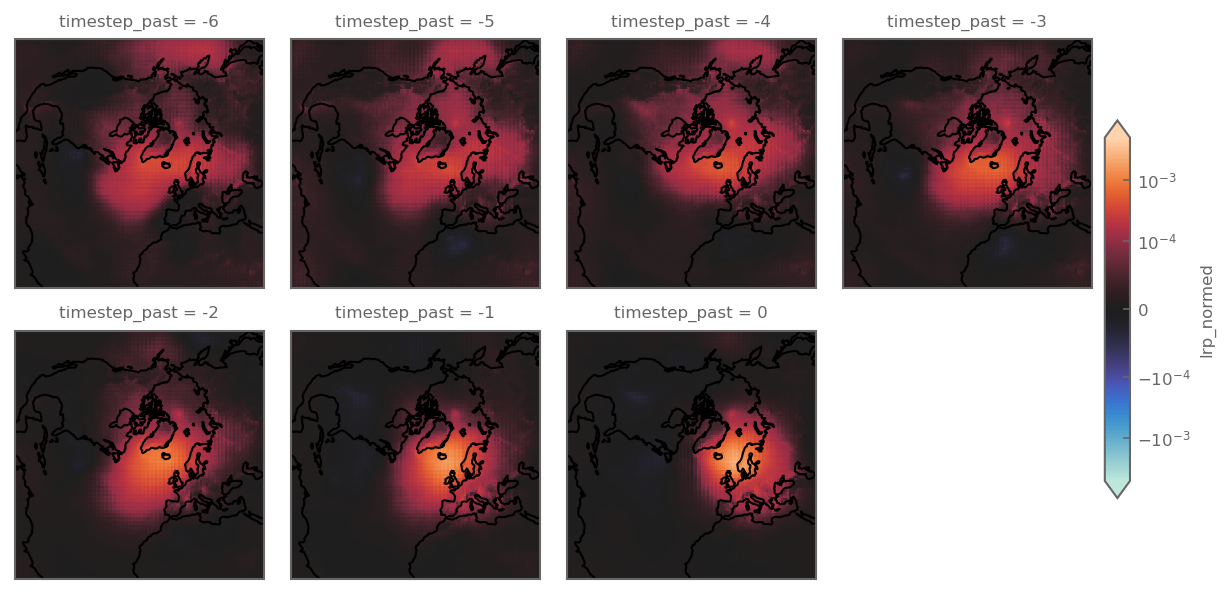

In [32]:
plot = ds_attrs_mean.plot(col='timestep_past', cmap='icefire', transform=proj,
                                                         subplot_kws=dict(projection=proj), vmax=.005,
                                                         aspect=1, size=2, rasterized=True, col_wrap=4,
                                                         cbar_kwargs=dict(extend='both', shrink=.7, pad=.01, aspect=15),
                                                         norm = mpl.colors.SymLogNorm(linthresh=0.0001))
for k,ax in enumerate(plot.axs.flatten()[:-1]):
    ax.coastlines()
    ax.set_extent((-1e7, 5e6,-1e7,5e6), crs=proj)

In [107]:
gdf_cyclones.to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data_watershed_thresh0.0005_buffer500_v2_zplus.geojson', driver='GeoJSON')


In [106]:
type(gdf_cyclones)

geopandas.geodataframe.GeoDataFrame

In [60]:
gdf_cyclones = df_

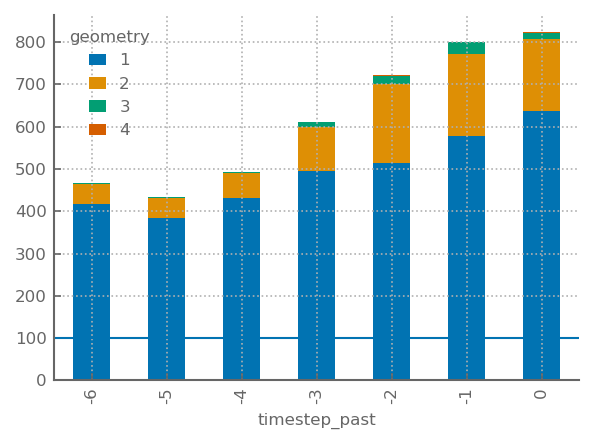

In [84]:
gdf_cyclones.query("patch_attributions>0.05").groupby(['timestep_past','time_of_event']).geometry.count().reset_index().groupby(['timestep_past','geometry']).time_of_event.count().unstack().plot.bar(stacked=True)
plt.axhline(100)
plt.grid()
plt.tight_layout()

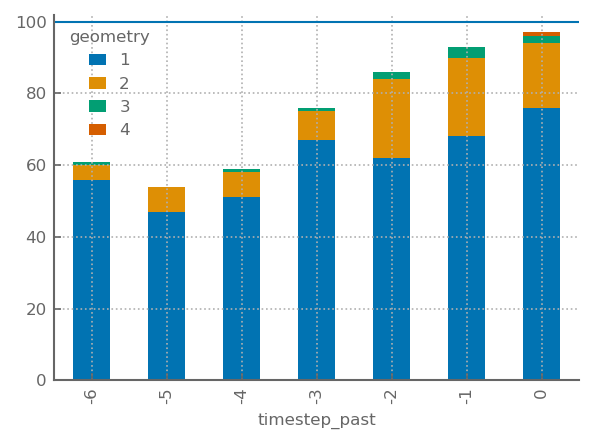

In [71]:
gdf_cyclones_random.query("patch_attributions>0.05").groupby(['timestep_past','time_of_event']).geometry.count().reset_index().groupby(['timestep_past','geometry']).time_of_event.count().unstack().plot.bar(stacked=True)
plt.axhline(100)
plt.grid()
plt.tight_layout()

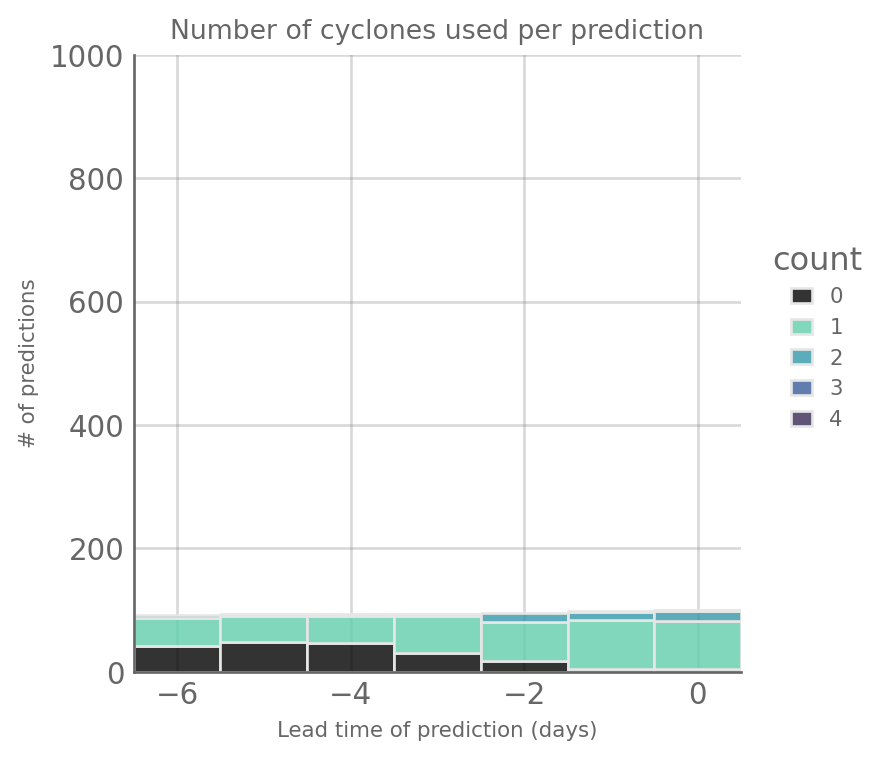

In [79]:
df_plot = gdf_cyclones.query("patch_attributions>0.05 & (is_cyclone)").groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')
df_count_all = gdf_cyclones.groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')*0
df_count_all.loc[df_plot.index] =df_plot
df_plot = df_count_all.reset_index()

(so.Plot(df_plot, x='timestep_past', color='count')
#  .add(so.Area( alpha=.6), so.Count(), so.Stack(), legend=True,)
 .add(so.Bars(alpha=.8, width=1, edgecolor='.9'), so.Count(),so.Stack(), legend=True)
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
#  .add(so.Dot(), so.Count(), so.Stack())
#  .facet(col='blo_category')
 .scale(color=so.Nominal(['0']+list(sns.color_palette('mako_r', n_colors=4)), order=[0,1,2,3,4], ) )
 .layout(size=(4,4))
 .limit(x=(-6.5,0.5), y=(0,1000))
 .label(title='Number of cyclones used per prediction', y='# of predictions', x='Lead time of prediction (days)', legend='Number of large positive patchs')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).plot().save('plots/cyclones_in_patches_per_prediction.svg', dpi=300, transparent=True)



In [69]:
gdf_cyclones.query("patch_attributions>0.05 & (is_cyclone)")

,index,cyclone_track_id,patch_attributions,patch_area,patch_pixel_count,geometry,time_of_event,timestep_past,is_cyclone,cyclone_date,patch_category,key,cyclone_msl,cyclone_lon,cyclone_lat,cyclone_x,cyclone_y
5,1979-01-02 63,63.0,0.058955,1.157852e+12,85.0,"POLYGON ((1633858.268 -6161417.323, 1633858.26...",1979-01-07,-5,True,1979-01-02,large positive,1979-01-02 63,99217.934317,17.402162,41.479960,1.669372e+06,-5.326267e+06
6,1979-01-02 67,67.0,0.117857,1.855354e+12,136.0,"POLYGON ((2224409.449 -6043307.087, 2224409.44...",1979-01-07,-5,True,1979-01-02,large positive,1979-01-02 67,99368.449537,25.550434,41.770970,2.391197e+06,-5.001913e+06
10,1979-01-03 200,200.0,0.057502,1.046252e+12,76.0,"POLYGON ((-1082677.165 807086.614, -1082677.16...",1979-01-07,-4,True,1979-01-03,large positive,1979-01-03 200,99440.126735,159.266497,77.940331,4.641371e+05,1.226134e+06
11,1979-01-03 207,207.0,0.107419,1.548453e+12,113.0,"POLYGON ((-4271653.543 -2736220.472, -4271653....",1979-01-07,-4,True,1979-01-03,large positive,1979-01-03 207,98423.798045,-62.746883,53.885742,-3.593141e+06,-1.850837e+06
13,1979-01-04 207,207.0,0.184576,2.594705e+12,190.0,"POLYGON ((-3208661.417 -2854330.709, -3208661....",1979-01-07,-3,True,1979-01-04,large positive,1979-01-04 207,96004.027854,-56.735144,64.554956,-2.341853e+06,-1.536254e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24804,2024-12-26 955824,955824.0,0.145324,2.078554e+12,152.0,"POLYGON ((-1555118.11 -3208661.417, -1555118.1...",2024-12-29,-3,True,2024-12-26,large positive,2024-12-26 955824,98384.445043,-36.773051,64.343516,-1.691066e+06,-2.262712e+06
24806,2024-12-27 955824,955824.0,0.418087,3.780458e+12,276.0,"POLYGON ((-1437007.874 -3444881.89, -1437007.8...",2024-12-29,-2,True,2024-12-27,large positive,2024-12-27 955824,97797.009193,-28.665021,65.675232,-1.282562e+06,-2.346047e+06
24809,2024-12-28 955824,955824.0,0.186023,1.799554e+12,131.0,"POLYGON ((-1200787.402 -3444881.89, -1200787.4...",2024-12-29,-1,True,2024-12-28,large positive,2024-12-28 955824,98269.606412,-9.323234,70.095391,-3.527292e+05,-2.148525e+06
24811,2024-12-28 955944,955944.0,0.340379,2.790006e+12,204.0,"POLYGON ((-374015.748 -3444881.89, -374015.748...",2024-12-29,-1,True,2024-12-28,large positive,2024-12-28 955944,97605.196759,11.612191,73.716337,3.573750e+05,-1.739116e+06


/tmp/ipykernel_3992043/3126187401.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.patch_pixel_count, np.arange(0,1001,10)),


Text(0.5, 0, 'Patch intensity\nShare of total positive attributions in patch')

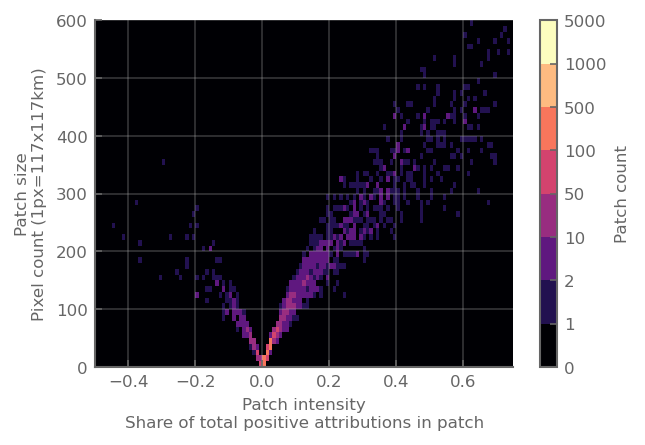

In [24]:
fig, ax = plt.subplots(figsize=(4.5,3))
df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.patch_pixel_count, np.arange(0,1001,10)),
                      pd.cut(gdf_cyclones.patch_attributions, np.arange(-1.5,1.1, .01)),
                      ]).geometry.count().to_xarray().rename('Patch count')
# df_plot['patch_attributions'] = df_patch.patch_attributions*100
df_plot.where(df_plot>=1).fillna(0).plot( vmin=1, cmap='magma', levels=[0,1,2,10,50, 100,500, 1000,5000])
ax.grid(linestyle='-', alpha=.3, zorder=10)
ax.set(ylim=(0,600), xlim=(-.5,.75))
# ax.set_ylim(0,50)
ax.set_ylabel('Patch size\nPixel count (1px=117x117km)')
ax.set_xlabel('Patch intensity\nShare of total positive attributions in patch')

/tmp/ipykernel_3992043/2870741444.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = pos_patch_cycs.groupby(["timestep_past","time_of_event",
/tmp/ipykernel_3992043/2870741444.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = df_.groupby(['timestep_past','cyclone_lon','cyclone_lat'])['count'].sum().reset_index()


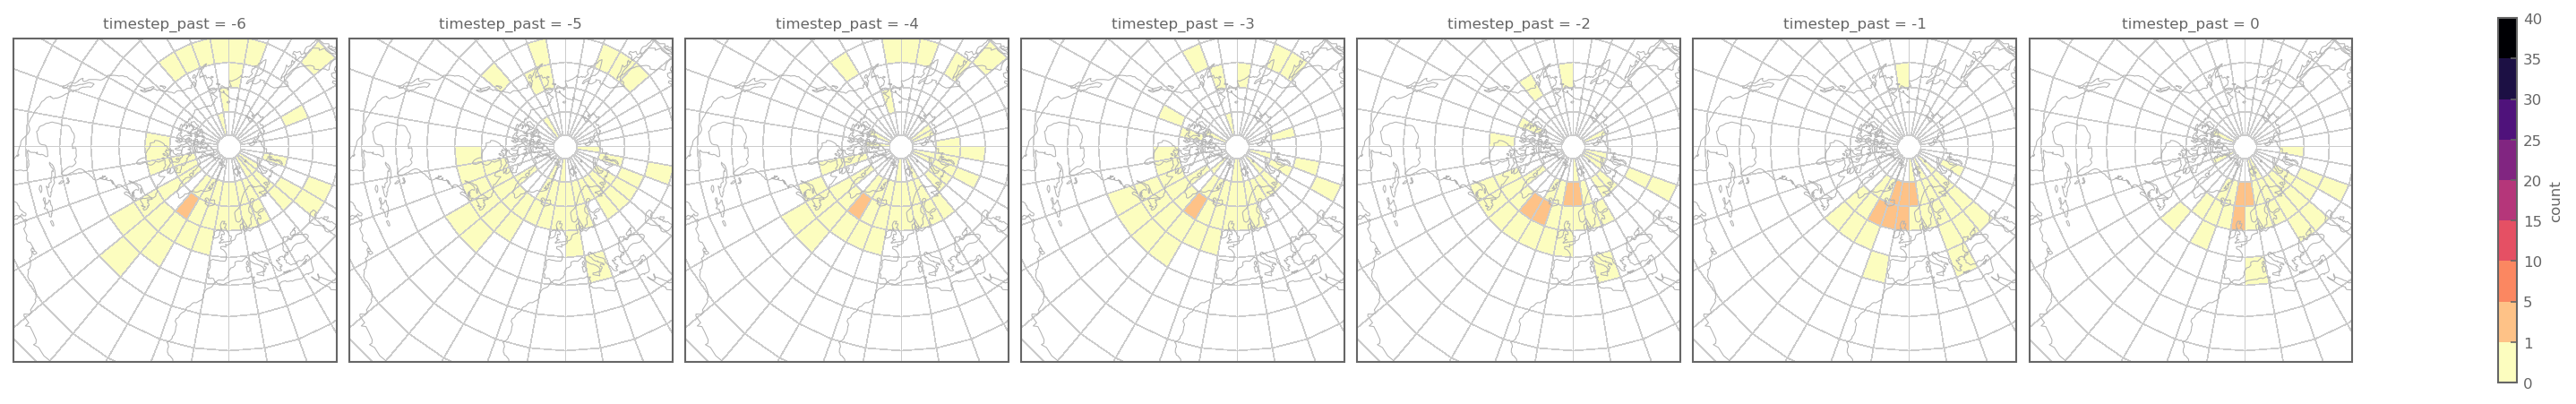

In [25]:
pos_patch_cycs = gdf_cyclones.query("is_cyclone&(patch_attributions>0.05)")
df_ = pos_patch_cycs.groupby(["timestep_past","time_of_event", 
                       pd.cut(pos_patch_cycs.cyclone_lon, np.arange(-190,181,10)),
                       pd.cut(pos_patch_cycs.cyclone_lat, np.arange(-45,91,10))]).geometry.count().rename('count').reset_index()
df_['count_one'] = df_['count']>0
df_ = df_.groupby(['timestep_past','cyclone_lon','cyclone_lat'])['count'].sum().reset_index()
df_['cyclone_lon'] = [k.mid for k in df_.cyclone_lon]
df_['cyclone_lat'] = [k.mid for k in df_.cyclone_lat]

ds_ = df_.set_index(['timestep_past','cyclone_lon','cyclone_lat'])['count'].to_xarray()/928*100

plot = ds_.where(ds_>0).plot(col='timestep_past', transform = ccrs.PlateCarree(),
         subplot_kws=dict(projection=proj), x='cyclone_lon', y='cyclone_lat', cmap='magma_r',
         levels=[0,1,5,10,15,20,25,30,35,40], edgecolors='.8', linewidth=.3)

for ax in plot.axs.flatten():
    # ax.coastlines()
    ax.set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)
    ax.coastlines(color='.7', lw=.5)
    # sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
    # gl = ax.gridlines(
    #     crs=ccrs.PlateCarree(),
    #     draw_labels=False,       # add tick labels
    #     linewidth=0.4,
    #     linestyle="-",
    #     alpha=0.5,
    #     zorder=2,
    #     color='.7'
    # )
    # gl.ylines=False


<GeoAxes: >

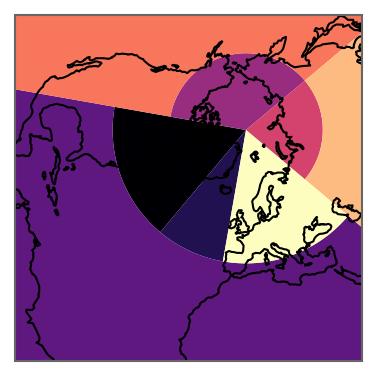

In [72]:
import matplotlib.patches as mpatches
fig, ax = plt.subplots(subplot_kw=dict(projection=proj))

ax.coastlines()
ax.set_extent((-1e7, 5e6, -1e7, 5e6), crs=proj)
import numpy as np
from shapely.geometry import Polygon
import shapely
# from shapely.ops import cascaded_union

def get_polygon(lon_min, lon_max, lat_min, lat_max,
                polygon_kwargs = dict(closed=True, facecolor='orange', alpha=0.5)):
    points_lon = list(np.linspace(lon_min, lon_max, 100)) + [lon_max for k in range(100)] + list(np.linspace(lon_max, lon_min, 100)) + [lon_min for k in range(100)]
    points_lat =  [lat_min for k in range(100)] + list(np.linspace(lat_min, lat_max, 100)) + [lat_max for k in range(100)]+ list(np.linspace(lat_max, lat_min, 100))
    vertices = list(zip(points_lon, points_lat))
    polygon_patch = mpatches.Polygon(vertices, transform=ccrs.PlateCarree(), **polygon_kwargs)
    return polygon_patch



def get_shapely_polygon(lon_min, lon_max, lat_min, lat_max,):
    points_lon = list(np.linspace(lon_min, lon_max, 100)) + [lon_max for k in range(100)] + list(np.linspace(lon_max, lon_min, 100)) + [lon_min for k in range(100)]
    points_lat =  [lat_min for k in range(100)] + list(np.linspace(lat_min, lat_max, 100)) + [lat_max for k in range(100)]+ list(np.linspace(lat_max, lat_min, 100))
    
    vertices = list(zip(points_lon, points_lat))
    polygon = Polygon(vertices, )
    return polygon

def get_shapely_polygon_from_points(p1, p2, p3, p4, n=100):
    points = []
    corners = [p1, p2, p3, p4, p1]  # close the loop
    for (x0, y0), (x1, y1) in zip(corners[:-1], corners[1:]):
        xs = np.linspace(x0, x1, n, endpoint=False)
        ys = np.linspace(y0, y1, n, endpoint=False)
        points.extend(zip(xs, ys))
    return Polygon(points)


# NAm = get_shapely_polygon(-100,-120,30,90,)
WestAtl = get_shapely_polygon(-40,-100,40,90)
EastAtl = get_shapely_polygon(-10,-40,40,90)
Tropics = get_shapely_polygon(-100,50,-10,40)


Arctic1 = get_shapely_polygon(130,360-100,60,90)
# Arctic2 = get_shapely_polygon(0,360,80,90)

ArcticAsia = get_shapely_polygon(130,50,60,90)
Pacific1 = get_shapely_polygon(130,360-100,0,60)
# Pacific2 = get_shapely_polygon(-100,-110,0,30)

Asia = get_shapely_polygon(130,50,0,60)
# Norge = get_shapely_polygon(-10,50,50,80)
Europe = get_shapely_polygon(-10,50,40,90)

palette = sns.color_palette(sns.color_palette('rocket',7)[1:6][::-1] + sns.color_palette('mako',6)[-5:])

gdf_sectors = gpd.GeoDataFrame(geometry=[
                                 WestAtl,
                                 EastAtl,
                                 Tropics,
                                 shapely.unary_union([Arctic1,]),
                                 ArcticAsia,
                                 shapely.unary_union([Pacific1]),
                                 Asia,
                                 # Norge,
                                 Europe
                                 ], 
                        index = [
                                'West Atlantic',
                                'East Atlantic',
                                'Tropics',
                                'Arctic',
                                'Arctic Asia',
                                'Pacific',
                                'Asia',
                                # 'Norway',
                                'Europe'
                                ],         
                        crs=ccrs.PlateCarree())

gdf_sectors.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='magma', legend=True)



In [86]:
from shapely.geometry import Point
geometry = [Point(xy) for xy in zip(gdf_cyclones.cyclone_lon, gdf_cyclones.cyclone_lat)]

# create GeoDataFrame
gdf_cyclones_center = gpd.GeoDataFrame(
    geometry=geometry,
    crs="EPSG:4326"   # WGS84 lon/lat
)
cyclones_with_sector = gpd.sjoin(
    gdf_cyclones_center.to_crs(proj),
    gdf_sectors.to_crs(proj),
    how="left",
    predicate="within"   # or "intersects" if needed
)
gdf_cyclones['cyclone_region'] = cyclones_with_sector.index_right
gdf_cyclones_random['cyclone_region'] = cyclones_with_sector.index_right

# gdf_cyclones

(0.0, 800.0)

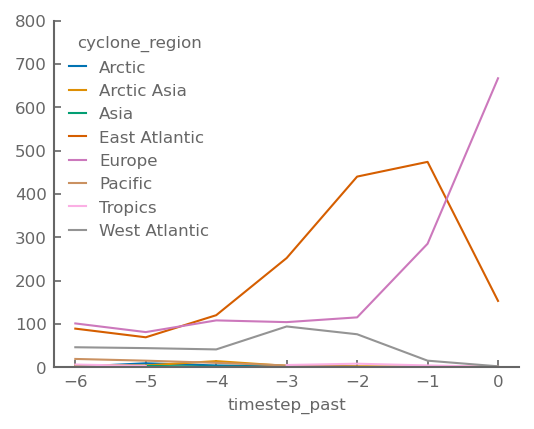

In [91]:
df_counts = gdf_cyclones.reset_index().query("patch_attributions>0.1").groupby(['time_of_event','timestep_past','cyclone_region']).cyclone_msl.count().reset_index()
df_counts = df_counts.query("cyclone_msl>0")
df_counts.groupby(['timestep_past','cyclone_region']).cyclone_msl.count().unstack().plot(   )
plt.ylim(0,800)

(0.0, 100.0)

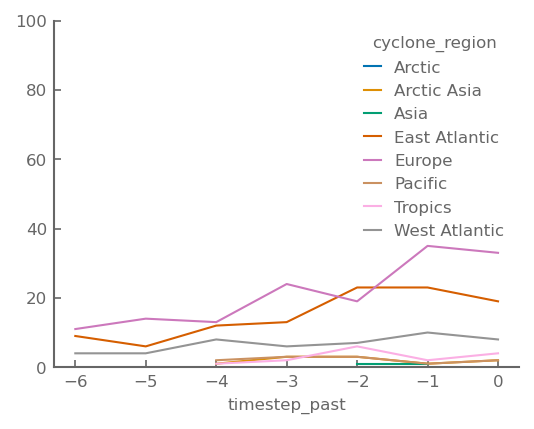

In [77]:
df_counts = gdf_cyclones_random.reset_index().query("patch_attributions>0.05").groupby(['time_of_event','timestep_past','cyclone_region']).cyclone_msl.count().reset_index()
df_counts = df_counts.query("cyclone_msl>0")
df_counts.groupby(['timestep_past','cyclone_region']).cyclone_msl.count().unstack().plot(   )
plt.ylim(0,100)

/tmp/ipykernel_3992043/436754341.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  gdf_cyclones_random.query("time_of_event=='1979-01-07' & timestep_past==-6+@k & patch_attributions>0.05").plot(ax=plot.axs.flat[k], color='none', edgecolor='1', transform=proj)
/tmp/ipykernel_3992043/436754341.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  gdf_cyclones_random.query("time_of_event=='1979-01-07' & timestep_past==-6+@k & patch_attributions>0.05").plot(ax=plot.axs.flat[k], color='none', edgecolor='1', transform=proj)
/tmp/ipykernel_3992043/436754341.py:3: FutureWarning: The be

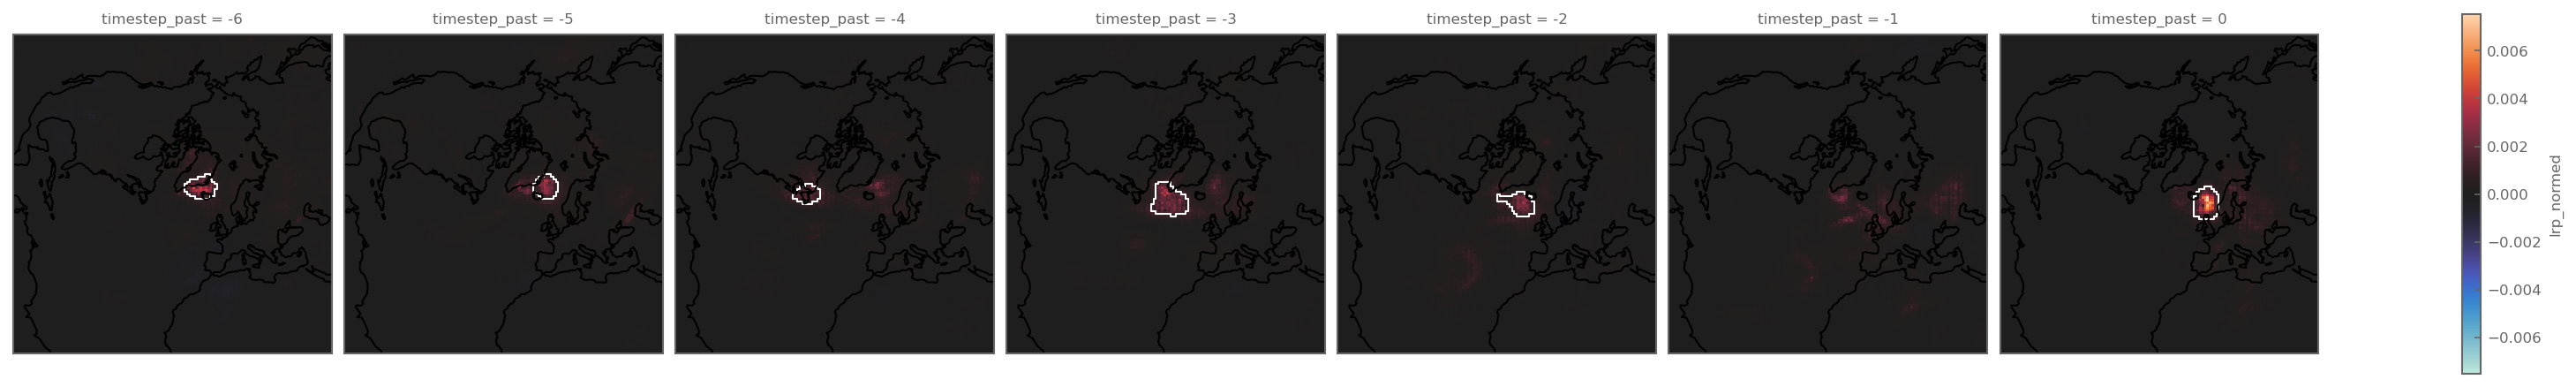

In [82]:
plot = ds_attrs_randomized.isel(time_of_event=0).lrp_normed.plot(col='timestep_past', cmap='icefire', subplot_kws=dict(projection=proj), transform=proj, x='x',y='y')
for k in range(7):
    gdf_cyclones_random.query("time_of_event=='1979-01-07' & timestep_past==-6+@k & patch_attributions>0.05").plot(ax=plot.axs.flat[k], color='none', edgecolor='1', transform=proj)
    plot.axs.flat[k].coastlines()

In [44]:
ds_attrs.isel(time_of_event=0).time_of_event

<xarray.DataArray 'time_of_event' ()> Size: 8B
array('1979-01-07T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    quantile       float64 8B 0.95
    time_of_event  datetime64[ns] 8B 1979-01-07

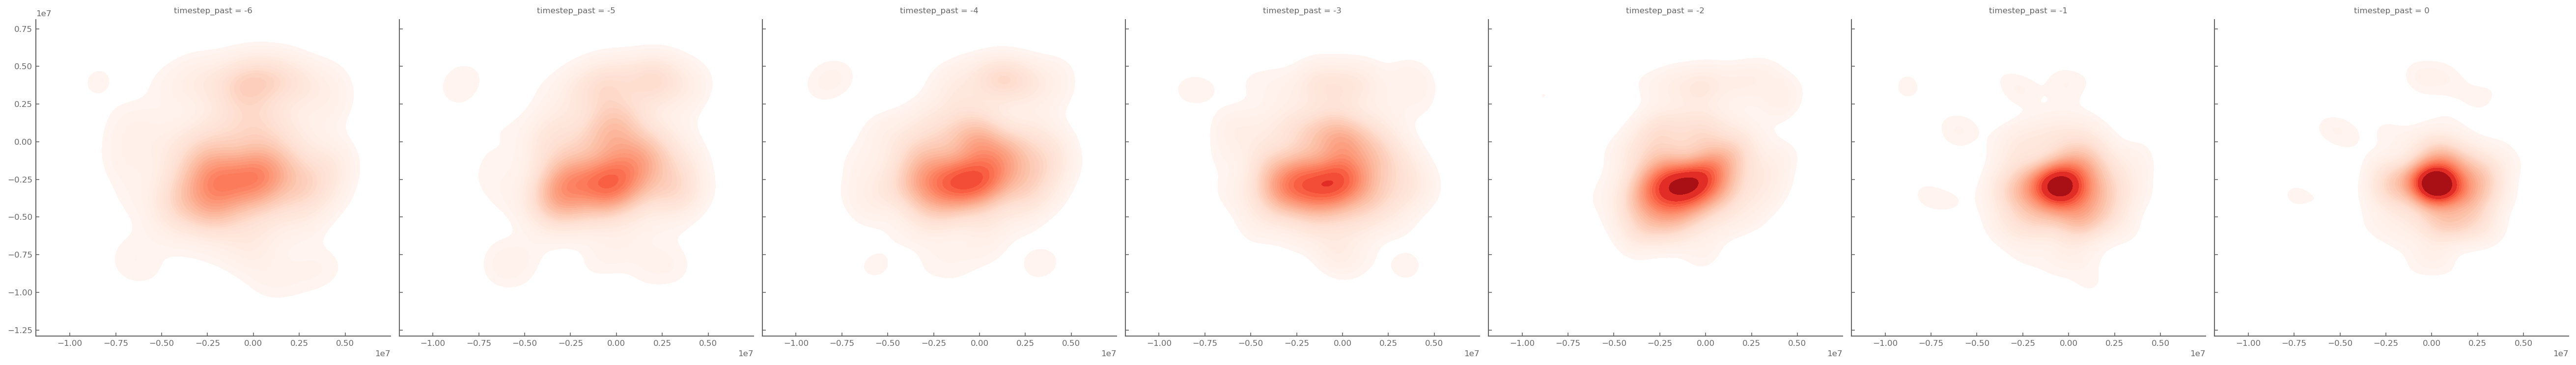

In [41]:
x = gdf_cyclones.centroid.x.values
y =  gdf_cyclones.centroid.y.values
timestep_past = gdf_cyclones.timestep_past
sns.displot(
    kind='kde',
    x=x,
    y=y,
    col=timestep_past,
    fill=True,
    cmap="Reds",
    levels=30,
    thresh=0.05
)

In [ ]:
gdf_cyclones.geometry

,index,cyclone_track_id,patch_attributions,patch_area,patch_pixel_count,geometry,time_of_event,timestep_past,is_cyclone,cyclone_date,patch_category,key,cyclone_msl,cyclone_lon,cyclone_lat,cyclone_x,cyclone_y,cyclone_region
0,1979-01-01 9,9.0,0.224901,2.720255e+12,199.0,"POLYGON ((-846456.693 -3090551.181, -846456.69...",1979-01-07,-6,True,1979-01-01,large positive,1979-01-01 9,100280.337114,-16.353258,66.703640,-7.201089e+05,-2.454110e+06,East Atlantic
1,1979-01-02 0,NaN,0.033822,7.533015e+11,55.0,"POLYGON ((-2027559.055 -1318897.638, -2027559....",1979-01-07,-6,False,1979-01-01,large neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1979-01-02 9,9.0,0.247628,3.250357e+12,237.0,"POLYGON ((-492125.984 -3208661.417, -492125.98...",1979-01-07,-5,True,1979-01-02,large positive,1979-01-02 9,99926.784449,-10.505497,67.502952,-4.499136e+05,-2.426217e+06,East Atlantic
3,1979-01-02 95,95.0,0.016014,3.766508e+11,28.0,"POLYGON ((3051181.102 -3917322.835, 3051181.10...",1979-01-07,-5,True,1979-01-02,large neutral,1979-01-02 95,98898.269159,40.515770,49.945617,2.934920e+06,-3.434435e+06,Europe
4,1979-01-03 5,5.0,0.005188,1.395003e+11,10.0,"POLYGON ((-1437007.874 -2972440.945, -1437007....",1979-01-07,-4,True,1979-01-03,large neutral,1979-01-03 5,100349.531446,-13.663657,61.282392,-7.500222e+05,-3.085218e+06,East Atlantic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2969,1979-01-02 0,NaN,0.005875,1.534503e+11,11.0,"POLYGON ((-1318897.638 334645.669, -1318897.63...",1984-10-20,-3,False,1984-10-17,large neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2970,1984-10-18 118549,118549.0,0.301606,4.185008e+12,306.0,"POLYGON ((-964566.929 -4625984.252, -1082677.1...",1984-10-20,-2,True,1984-10-18,large positive,1984-10-18 118549,95790.050725,-5.155888,56.859401,-3.315640e+05,-3.674618e+06,Europe
2971,1984-10-18 118630,118630.0,0.225185,2.552855e+12,186.0,"POLYGON ((-1437007.874 -4271653.543, -1437007....",1984-10-20,-2,True,1984-10-18,large positive,1984-10-18 118630,98209.943813,-27.792222,63.975812,-1.336628e+06,-2.535975e+06,East Atlantic
2972,1984-10-19 118677,118677.0,0.481786,5.677661e+12,415.0,"POLYGON ((-19685.039 -4389763.78, -19685.039 -...",1984-10-20,-1,True,1984-10-19,large positive,1984-10-19 118677,97239.343680,-7.814556,57.941028,-4.844159e+05,-3.529653e+06,Europe
